# Case Study: Doctor Visit Analysis using Python


## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset and Display First 15 Rows

In [2]:
df = pd.read_csv("Healthcare Analytics for Doctor Visits.csv")
df.head(15)

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no
5,6,1,female,0.19,0.35,5,1,9,no,no,no,yes,no
6,7,1,female,0.19,0.55,4,0,2,no,no,no,no,no
7,8,1,female,0.19,0.15,3,0,6,no,no,no,no,no
8,9,1,female,0.19,0.65,2,0,5,yes,no,no,no,no
9,10,1,male,0.19,0.15,1,0,0,yes,no,no,no,no


## 2. Display Complete Information About the Columns of the Dataset such as Column Name, Count, Data Type and Overall Memory Usage

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


## 3. Find Out the Total Number of People Based on Their Count of Illness

In [4]:
df["illness"].value_counts().sort_index()

illness
0    1554
1    1638
2     946
3     542
4     274
5     236
Name: count, dtype: int64

## 4. Visualize and Analyse the Maximum, Minimum and Median Income

Maximum Income: 1.5
Minimum Income: 0.0
Median Income: 0.55


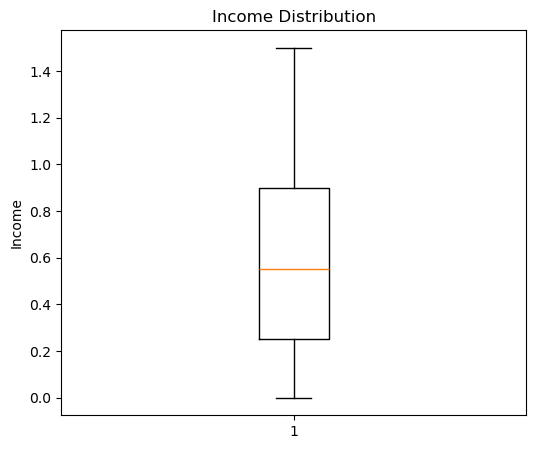

In [5]:
print("Maximum Income:", df["income"].max())
print("Minimum Income:", df["income"].min())
print("Median Income:", df["income"].median())

plt.figure(figsize=(6,5))
plt.boxplot(df["income"])
plt.ylabel("Income")
plt.title("Income Distribution")
plt.show()

## 5. Find Out the Number of Days of Reduced Activity of Male and Female Separately Due to Illness

In [6]:
reduced_days = df.groupby("gender")["reduced"].sum()

print(reduced_days)

gender
female    2636
male      1837
Name: reduced, dtype: int64


## 6. Visualize Whether There Are Any Missing Values in the Dataset Based on a Heatmap

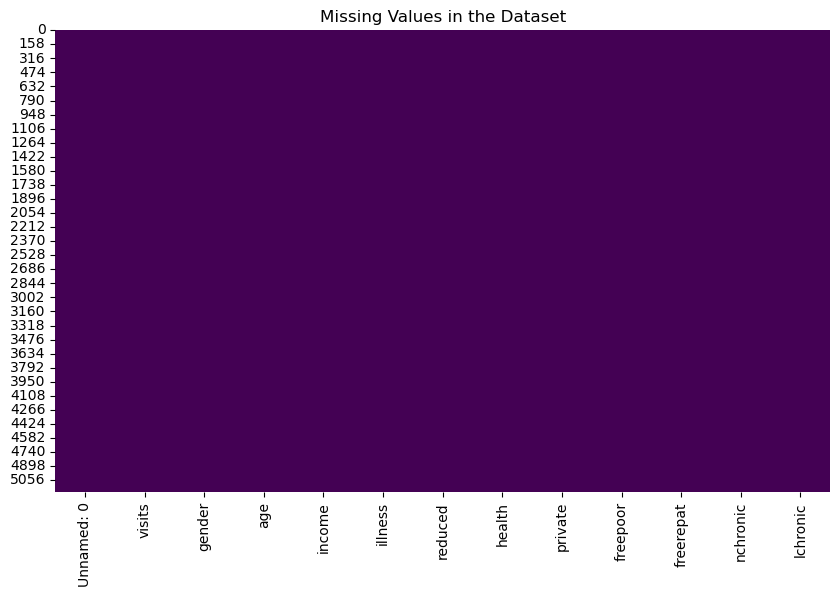

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values in the Dataset")
plt.show()

## 7. Find Out the Correlation Between Different Variables in the Given Dataset

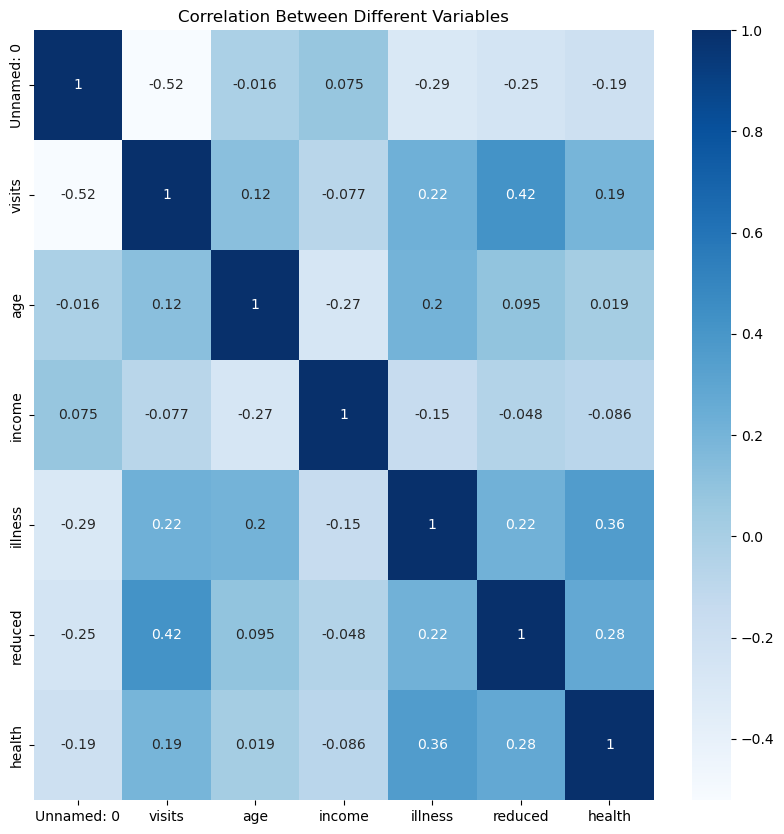

In [8]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Between Different Variables")
plt.show()

## 8. Analyse How the Income of a Patient Affects the Number of Visits to the Hospital

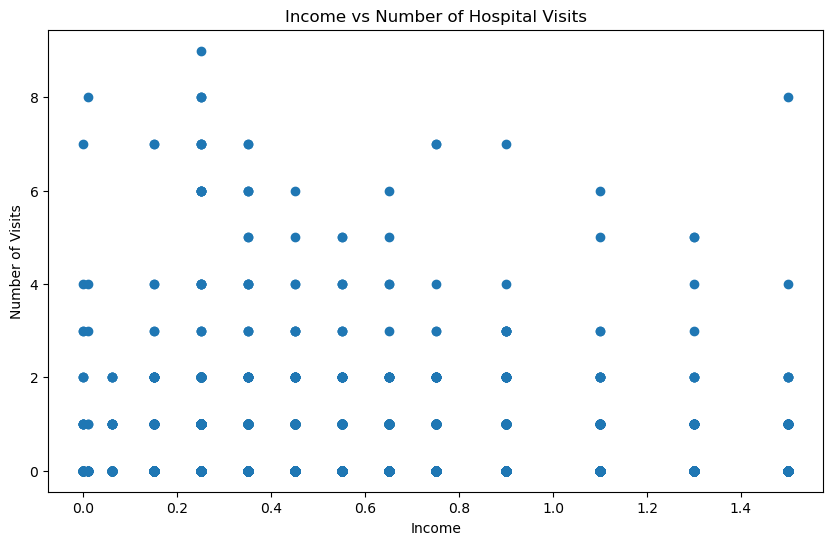

In [9]:
plt.figure(figsize=(10,6))

plt.scatter(df["income"], df["visits"])

plt.xlabel("Income")
plt.ylabel("Number of Visits")
plt.title("Income vs Number of Hospital Visits")

plt.show()

## 9. Count and Visualize the Number of Males and Females Affected by Illness

gender
female    2023
male      1613
Name: count, dtype: int64


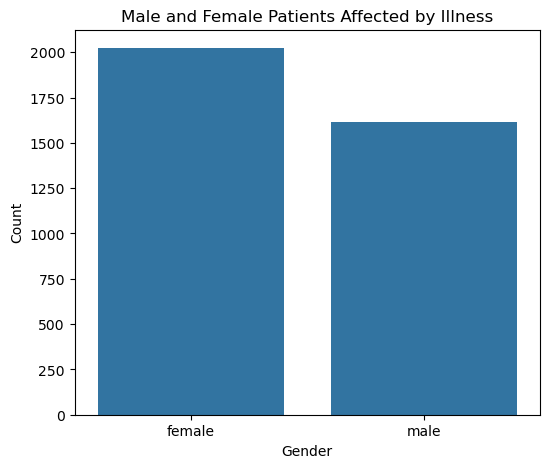

In [10]:
affected = df[df["illness"] > 0]

print(affected["gender"].value_counts())

plt.figure(figsize=(6,5))

sns.countplot(x="gender", data=affected)

plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Male and Female Patients Affected by Illness")

plt.show()

## 10. Visualize the Percentage of People Getting Government Health Insurance Due to Low Income, Due to Old Age and the Percentage of People Having Private Health Insurance

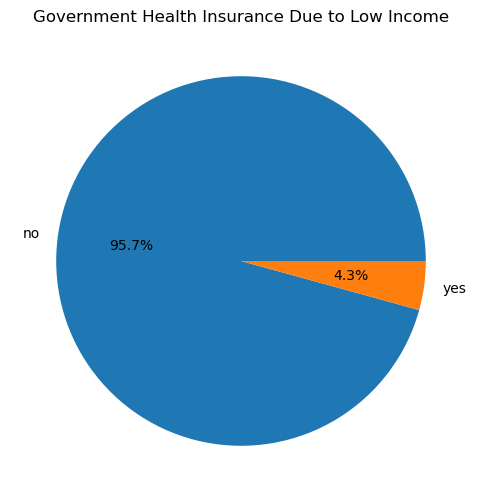

In [11]:
low_income = df["freepoor"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    low_income.values,
    labels=low_income.index,
    autopct="%1.1f%%"
)

plt.title("Government Health Insurance Due to Low Income")
plt.show()

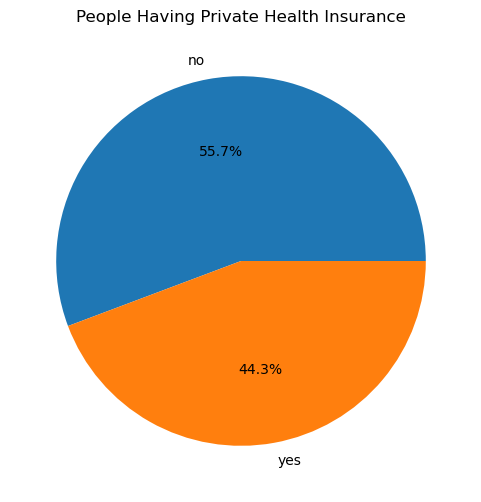

In [12]:
private_insurance = df["private"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    private_insurance.values,
    labels=private_insurance.index,
    autopct="%1.1f%%"
)

plt.title("People Having Private Health Insurance")
plt.show()

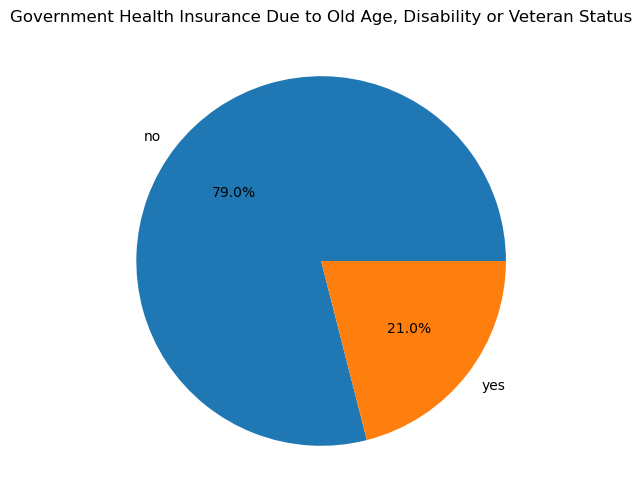

In [13]:
old_age_insurance = df["freerepat"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    old_age_insurance.values,
    labels=old_age_insurance.index,
    autopct="%1.1f%%"
)

plt.title("Government Health Insurance Due to Old Age, Disability or Veteran Status")
plt.show()

## 11. Plot a Horizontal Bar Chart to Analyze the Reduced Days of Activity Due to Illness Based on Gender

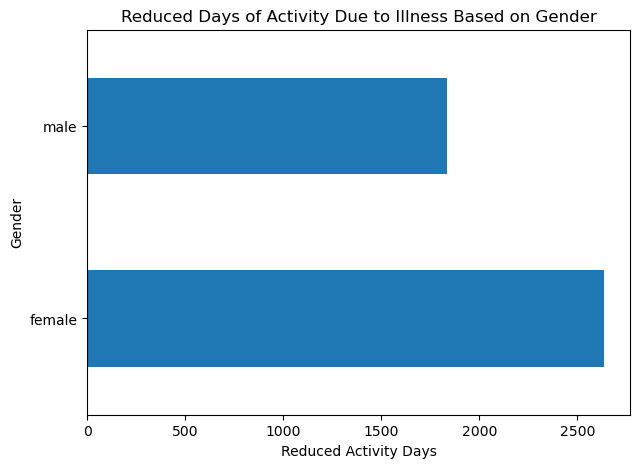

In [14]:
reduced_gender = df.groupby("gender")["reduced"].sum()

plt.figure(figsize=(7,5))

reduced_gender.plot(kind="barh")

plt.xlabel("Reduced Activity Days")
plt.ylabel("Gender")
plt.title("Reduced Days of Activity Due to Illness Based on Gender")

plt.show()